# Gromov-Wasserstein

In this tutorial, we present the {class}`~ott.solvers.quadratic.gromov_wasserstein.GromovWasserstein` entropic solver, as presented in {cite}`peyre:16`. The GW problem {cite}`memoli:11` proposes to match two point clouds that may lie in two different spaces, each endowed with its own geometry, using a quadratic assignment problem {cite}`koopmans:57`.

We illustrate this by aligning a 2-d to a 3-d {class}`point cloud <ott.geometry.pointcloud.PointCloud>`, see also {doc}`../quadratic/200_gromov_wasserstein_multiomics` for a more realistic application to single-cell omics.

In [ ]:
import functools

import jax
import jax.numpy as jnp
import numpy as np

import matplotlib.pyplot as plt
from IPython import display
from matplotlib import animation

from ott.geometry import pointcloud
from ott.solvers import quadratic

## Matching across spaces

We generate samples from a spiral in 2-d and a Swiss roll in 3-d.

In [2]:
def sample_spiral(
    n, min_radius, max_radius, key, min_angle=0, max_angle=10, noise=1.0
):
    radius = jnp.linspace(min_radius, max_radius, n)
    angles = jnp.linspace(min_angle, max_angle, n)
    noise = jax.random.normal(key, (2, n)) * noise
    x = (radius + noise[0, :]) * jnp.cos(angles)
    y = (radius + noise[1, :]) * jnp.sin(angles)
    return jnp.stack((x, y)).T


def sample_swiss_roll(
    n, min_radius, max_radius, length, key, min_angle=0, max_angle=10, noise=0.1
):
    keys = jax.random.split(key, 2)
    spiral = sample_spiral(
        n, min_radius, max_radius, keys[0], min_angle, max_angle, noise
    )
    third_axis = 0.1 * jax.random.uniform(keys[1], (n, 1)) * length
    swiss_roll = jnp.hstack((spiral[:, 0:1], third_axis, spiral[:, 1:]))
    return swiss_roll


def plot(
    swiss_roll, spiral, colormap_angles_swiss_roll, colormap_angles_spiral
):
    fig = plt.figure(figsize=(11, 5))
    ax = fig.add_subplot(1, 2, 1)
    ax.scatter(spiral[:, 0], spiral[:, 1], c=colormap_angles_spiral)
    ax.grid()
    ax = fig.add_subplot(1, 2, 2, projection="3d")
    ax.view_init(7, -80)
    ax.scatter(
        swiss_roll[:, 0],
        swiss_roll[:, 1],
        swiss_roll[:, 2],
        c=colormap_angles_swiss_roll,
    )
    ax.set_adjustable("box")
    plt.show()

In [3]:
# Generation parameters
n_spiral = 400
n_swiss_roll = 500
length = 10
min_radius = 0.3
max_radius = 1
noise = 0.05
min_angle = 0
max_angle = 9
angle_shift = 3

Shapes:  (400, 2) (500, 3)


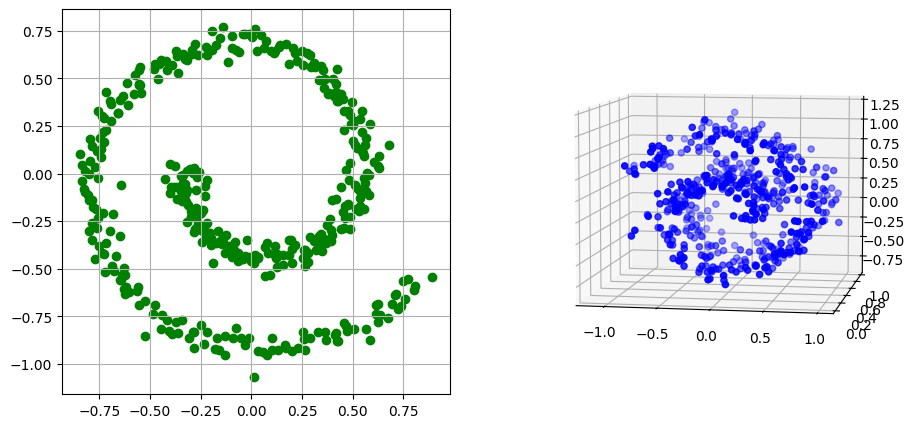

In [12]:
spiral = sample_spiral(
    n_spiral,
    min_radius,
    max_radius,
    key=jax.random.key(0),
    min_angle=min_angle + angle_shift,
    max_angle=max_angle + angle_shift,
    noise=noise,
)

swiss_roll = sample_swiss_roll(
    n_swiss_roll,
    min_radius,
    max_radius,
    key=jax.random.key(1),
    length=length,
    min_angle=min_angle,
    max_angle=max_angle,
)

print("Shapes: ", spiral.shape, swiss_roll.shape)
plot(swiss_roll, spiral, "blue", "green")

We define two {class}`point clouds <ott.geometry.pointcloud.PointCloud>` to describe each of these point clouds, each using (by default) the {class}`~ott.geometry.costs.SqEuclidean` cost function.

5 outer iterations were needed.
The outer loop of Gromov Wasserstein has converged: True
The final regularized GW cost is: 0.121


Text(0, 0.5, 'Regularized Cost')

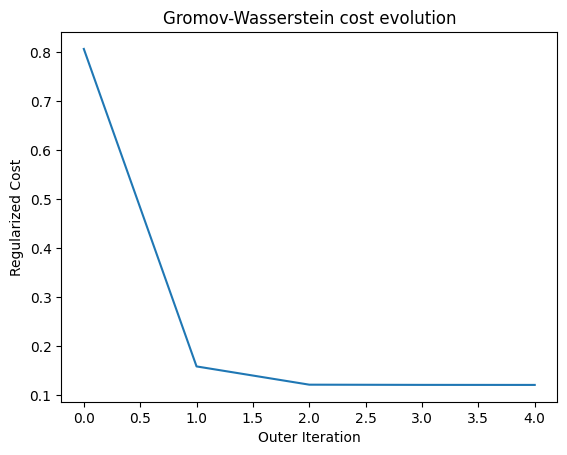

In [22]:
# Instantiate the Quadratic Alignment Problem
geom_xx = pointcloud.PointCloud(spiral)
geom_yy = pointcloud.PointCloud(swiss_roll)

# Instantiate a jitted Gromov-Wasserstein solver
solver = jax.jit(functools.partial(quadratic.solve, min_iterations=0))

out = solver(geom_xx, geom_yy, epsilon=0.005)

print(f"{out.n_iters} outer iterations were needed.")
print(f"The outer loop of Gromov Wasserstein has converged: {out.converged}")
print(f"The final regularized GW cost is: {out.reg_gw_cost:.3f}")
plt.plot(out.costs[: out.n_iters])
plt.title("Gromov-Wasserstein cost evolution")
plt.xlabel("Outer Iteration")
plt.ylabel("Regularized Cost")

The resulting transport matrix between the two point clouds can be displayed:

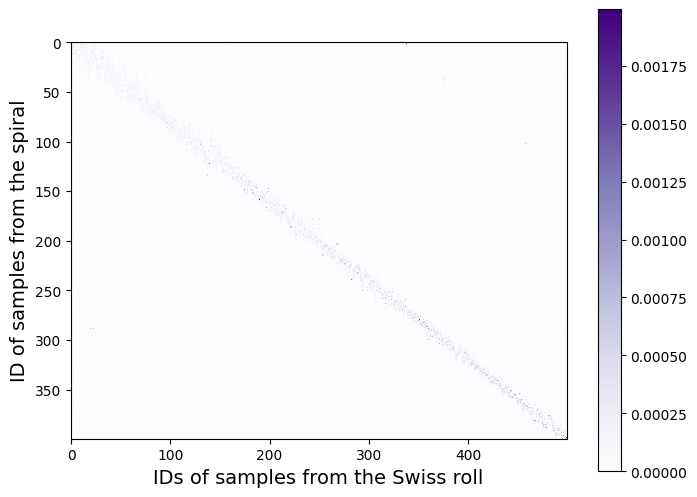

In [23]:
coupling_matrix = out.matrix
fig = plt.figure(figsize=(8, 6))
plt.imshow(coupling_matrix, cmap="Purples")
plt.xlabel(
    "IDs of samples from the Swiss roll", fontsize=14
)  # IDs are ordered from center to outer part
plt.ylabel(
    "ID of samples from the spiral", fontsize=14
)  # IDs are ordered from center to outer part
plt.colorbar()
plt.show()

The larger the regularization parameter `epsilon` is, the more diffuse the transport matrix becomes, as we can see in the animation below.

In [25]:
# Animates the transport matrix
fig = plt.figure(figsize=(8, 6))
im = plt.imshow(coupling_matrix, cmap="Purples")
plt.xlabel(
    "IDs of samples from the Swiss roll", fontsize=14
)  # IDs are ordered from center to outer part
plt.ylabel(
    "IDs of samples from the spiral", fontsize=14
)  # IDs are ordered from center to outer part
plt.colorbar()


# Initialization function
def init():
    im.set_data(np.zeros(coupling_matrix.shape))
    return [im]


epsilons = 10 ** np.linspace(-2.5, 1, 10)
# Animation function


def animate(i):
    array = im.get_array()
    out = solver(geom_xx, geom_yy, epsilon=epsilons[i])
    im.set_array(out.matrix)
    im.set_clim(0, jnp.max(out.matrix[:]))
    plt.title("epsilon = " + str(epsilons[i]))
    return [im]


# Call the animator
anim = animation.FuncAnimation(
    fig,
    animate,
    init_func=init,
    frames=[i for i in range(len(epsilons))],
    interval=1500,
    blit=True,
)

html = display.HTML(anim.to_jshtml())
display.display(html)
plt.close()

To better understand the correspondence found by the {class}`~ott.solvers.quadratic.gromov_wasserstein.GromovWasserstein` solver,
we plot in the same color, for each point in the spiral, the point in the Swiss roll it is the most coupled to.

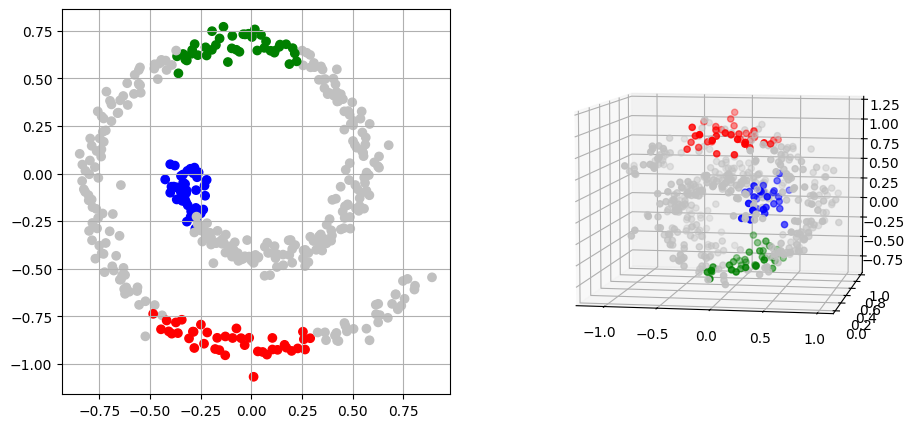

In [27]:
# For each sample from the spiral, we get the most coupled point from the Swiss roll
indices_swiss_roll = jnp.array(np.argmax(coupling_matrix, axis=1))
# Sets colors to visualize matching of some areas between each shape
# IDs of spiral and Swiss roll are ordered from center to outer part
colors_input_spiral = (
    ["b"] * 40
    + ["silver"] * 160
    + ["g"] * 40
    + ["silver"] * 90
    + ["r"] * 40
    + ["silver"] * 30
)
colors_swiss_roll = np.array(["silver"] * 500)
colors_swiss_roll[indices_swiss_roll[:40]] = "b"
colors_swiss_roll[indices_swiss_roll[200:240]] = "g"
colors_swiss_roll[indices_swiss_roll[330:370]] = "r"

plot(swiss_roll, spiral, colors_swiss_roll, colors_input_spiral)